In [6]:
!python3 --version
!python3 -m pip install tensorflow pandas numpy scikit-learn matplotlib keras-tuner

Python 3.13.13
Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras_tuner as kt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical
from keras.optimizers import Adam

In [8]:
train = "../datasets/final_train.csv"
test = "../datasets/test.csv"

df = pd.read_csv(train)
test_df = pd.read_csv(test)

In [9]:
X = df.drop(columns=["label_tactic"]).values
y = df["label_tactic"].values

X_test = test_df.drop(columns=["label_tactic"]).values
y_test = test_df["label_tactic"].values

In [10]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

In [11]:
X = X.reshape(X.shape[0], X.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [15]:

def build_cnn(hp):
    model = Sequential()

    model.add(Conv1D(
        filters=hp.Int('filters', min_value=32, max_value=128, step=32),
        kernel_size=hp.Choice('kernel_size', [3,5,7]),
        activation='relu',
        input_shape=(X.shape[1], 1)
    ))

    model.add(MaxPooling1D(pool_size=2))

    model.add(Flatten())

    model.add(Dense(
        units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Float('lr', 1e-4, 1e-2, sampling='log')
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [17]:
tuner = kt.BayesianOptimization(
    build_cnn,
    objective='val_accuracy',
    max_trials=60,  
    directory='tuner_dir',
    project_name='cnn_bayes'
)

tuner.search(
    X, y_encoded,
    epochs=20,
    validation_split=0.2,
    batch_size=256,
    verbose=1
)

best_hp = tuner.get_best_hyperparameters(1)[0]

Trial 60 Complete [00h 00m 48s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 31m 25s


In [19]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold_accuracies = []
histories = []

fold = 1
for train_idx, val_idx in skf.split(X, y_encoded):
    print(f"\nFold {fold}/10")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    y_train_cat = y_train
    y_val_cat = y_val

    model = tuner.hypermodel.build(best_hp)

    history = model.fit(
        X_train,
        y_train_cat,
        epochs=200,
        batch_size=256,
        validation_data=(X_val, y_val_cat),
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
    fold_accuracies.append(val_acc)
    histories.append(history)

    print(f"Fold {fold} Validation Accuracy: {val_acc:.4f}")
    fold += 1


Fold 1/10
Epoch 1/200


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7285 - loss: 51.2389 - val_accuracy: 0.9059 - val_loss: 7.3258
Epoch 2/200
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9214 - loss: 4.4776 - val_accuracy: 0.9819 - val_loss: 0.0898
Epoch 3/200
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9635 - loss: 0.5501 - val_accuracy: 0.9641 - val_loss: 0.2804
Epoch 4/200
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9640 - loss: 0.6433 - val_accuracy: 0.9509 - val_loss: 0.7430
Epoch 5/200
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9475 - loss: 6.0342 - val_accuracy: 0.9944 - val_loss: 0.0712
Epoch 6/200
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9833 - loss: 0.2305 - val_accuracy: 0.9789 - val_loss: 0.1860
Epoch 7/200
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9766 - loss: 0.4151 - val_accuracy: 0.9288 - val_loss: 1.5587
Epoch 8/200
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9760 - loss: 0.5430 - val_accuracy: 0.982

In [20]:
print("\nCross-Validation Results")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Std Dev: {np.std(fold_accuracies):.4f}")


Cross-Validation Results
Mean Accuracy: 0.9966
Std Dev: 0.0035


In [23]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

final_model = build_cnn(best_hp)

final_history = final_model.fit(
    X,
    y_encoded,
    epochs=200,
    batch_size=256,
    verbose=1
)

Epoch 1/200


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7471 - loss: 39.8734 
Epoch 2/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9025 - loss: 4.6876
Epoch 3/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9687 - loss: 0.2599
Epoch 4/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9576 - loss: 0.5228
Epoch 5/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9724 - loss: 0.3629
Epoch 6/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9561 - loss: 3.2033
Epoch 7/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9857 - loss: 0.1279
Epoch 8/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9831 - loss: 0.1697
Epoch 9/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9820 - loss: 0.2176
Epoch 10/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9841 - loss: 0.1921
Epoch 11/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9845 - loss: 0.2252
Epoch 12/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/st

In [ ]:
#THIS WRONG
best_hp = tuner.get_best_hyperparameters(1)[0]

final_model = build_cnn(best_hp)
final_model.fit(
    X,
    y_encoded,
    epochs=200,
    batch_size=256,
    verbose=1
)
y_test_cat = y_test_encoded

test_loss, test_acc = final_model.evaluate(X_test, y_test_cat, verbose=0)

print(f"\nBest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/200


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7063 - loss: 54.7082 
Epoch 2/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9366 - loss: 3.0306
Epoch 3/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9441 - loss: 6.7976 
Epoch 4/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9701 - loss: 0.7986
Epoch 5/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9695 - loss: 0.8037
Epoch 6/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9709 - loss: 0.8448
Epoch 7/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9721 - loss: 0.9650
Epoch 8/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.7857
Epoch 9/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9823 - loss: 0.5094
Epoch 10/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9863 - loss: 0.2762
Epoch 11/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9815 - loss: 0.5723
Epoch 12/200
603/603 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/s

1633/1633 ━━━━━━━━━━━━━━━━━━━━ 1s 715us/step


<Figure size 1200x1200 with 0 Axes>

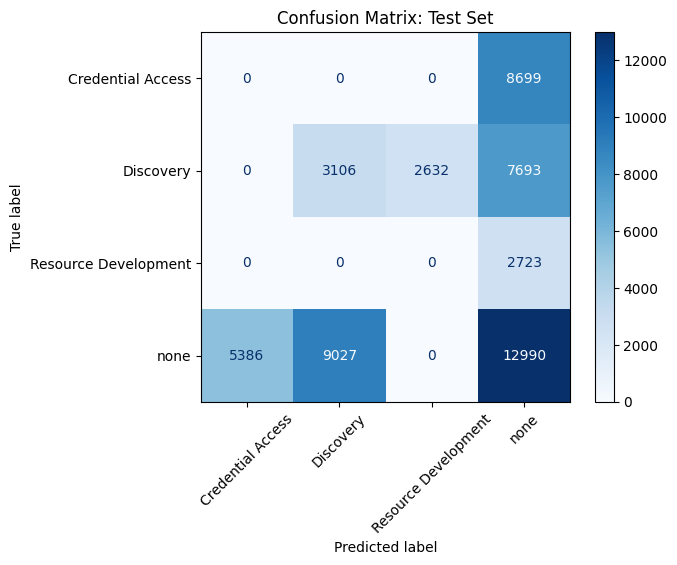

In [29]:
y_test_pred = np.argmax(final_model.predict(X_test), axis=1)

cm = confusion_matrix(y_test_encoded, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(12, 12))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix: Test Set")
plt.show()

1633/1633 ━━━━━━━━━━━━━━━━━━━━ 1s 721us/step

Classification Report
                      precision    recall  f1-score   support

   Credential Access       0.00      0.00      0.00      8699
           Discovery       0.26      0.23      0.24     13431
Resource Development       0.00      0.00      0.00      2723
                none       0.40      0.47      0.44     27403

            accuracy                           0.31     52256
           macro avg       0.17      0.18      0.17     52256
        weighted avg       0.28      0.31      0.29     52256



<Figure size 1200x1200 with 0 Axes>

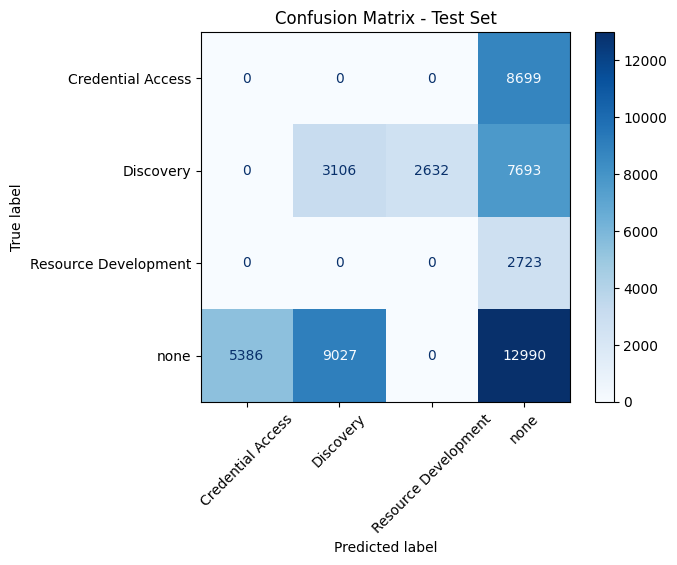


False Positive Rate (per class)
Credential Access: 0.1237
Discovery: 0.2325
Resource Development: 0.0531
none: 0.7691

Average FPR: 0.2946044061946592


In [30]:

y_test_pred = np.argmax(final_model.predict(X_test), axis=1)


print("\nClassification Report")
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)


cm = confusion_matrix(y_test_encoded, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(12, 12))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()


print("\nFalse Positive Rate (per class)")

fpr_list = []

for i in range(len(cm)):
    FP = cm[:, i].sum() - cm[i, i]
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
    fpr_list.append(fpr)
    
    print(f"{label_encoder.classes_[i]}: {fpr:.4f}")

print("\nAverage FPR:", np.mean(fpr_list))

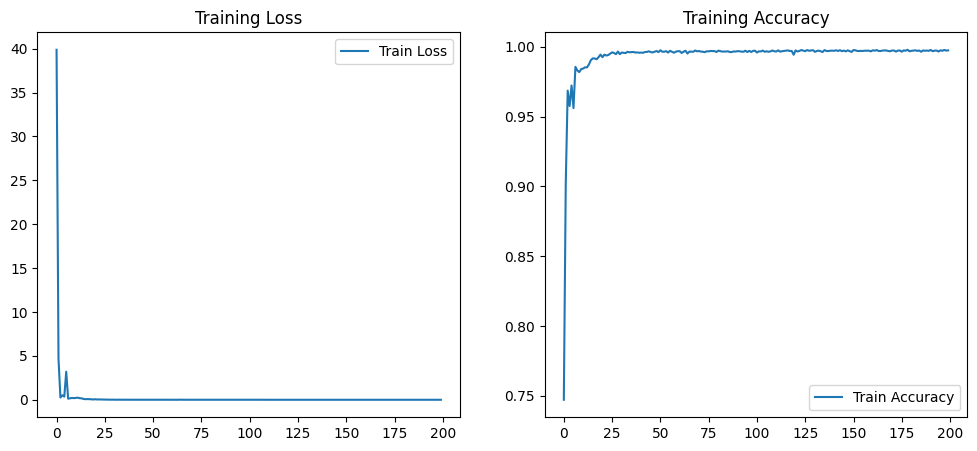

In [31]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(final_history.history["loss"], label="Train Loss")
plt.title("Training Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history["accuracy"], label="Train Accuracy")
plt.title("Training Accuracy")
plt.legend()

plt.show()